# Loan Approval Prediction
---
### Project Pipeline:
1. Load Data
2. Train/Test Split
3. EDA
4. Data Cleaning
5. Preprocessing
6. Dimensionality Reduction Comparison 
7. SVM Model + Hyperparameter Tuning (Best technique)
8. Evaluation

---
## Dataset Description

The dataset contains **20,000 loan applications** with **35 features** describing each applicant's financial profile. The target variable is `LoanApproved` (1 = Approved, 0 = Rejected).

### Feature Overview

| Feature | Type | Description |
|---------|------|-------------|
| `Age` | Numerical | Applicant's age in years |
| `AnnualIncome` | Numerical | Total yearly income in USD |
| `CreditScore` | Numerical | Credit rating score (300–850); higher means better creditworthiness |
| `EmploymentStatus` | Categorical | Employment type: Employed, Self-Employed, Unemployed, Retired |
| `EducationLevel` | Categorical | Highest education attained (High School → Doctorate) |
| `Experience` | Numerical | Years of work experience |
| `LoanAmount` | Numerical | Amount of loan requested in USD |
| `LoanDuration` | Numerical | Loan repayment period in months |
| `MaritalStatus` | Categorical | Applicant's marital status (Single, Married, Divorced, Widowed) |
| `NumberOfDependents` | Numerical | Number of people financially dependent on the applicant |
| `HomeOwnershipStatus` | Categorical | Whether the applicant owns, rents, or has a mortgage on their home |
| `MonthlyDebtPayments` | Numerical | Total monthly debt obligations in USD |
| `CreditCardUtilizationRate` | Numerical | Ratio of credit card balance to credit limit (0–1) |
| `NumberOfOpenCreditLines` | Numerical | Number of currently active credit accounts |
| `NumberOfCreditInquiries` | Numerical | Number of recent hard credit checks by lenders |
| `DebtToIncomeRatio` | Numerical | Ratio of monthly debt payments to monthly income |
| `BankruptcyHistory` | Binary | Whether the applicant has declared bankruptcy (0 = No, 1 = Yes) |
| `LoanPurpose` | Categorical | Purpose of the loan (Home, Auto, Education, Personal, Business, Debt Consolidation) |
| `PreviousLoanDefaults` | Numerical | Number of previously defaulted loans |
| `PaymentHistory` | Numerical | Score reflecting consistency of past payments (0–100) |
| `LengthOfCreditHistory` | Numerical | Number of years since the applicant's first credit account |
| `SavingsAccountBalance` | Numerical | Current balance in the applicant's savings account (USD) |
| `CheckingAccountBalance` | Numerical | Current balance in the applicant's checking account (USD) |
| `TotalAssets` | Numerical | Total value of all assets owned by the applicant (USD) |
| `TotalLiabilities` | Numerical | Total outstanding debts and obligations (USD) |
| `MonthlyIncome` | Numerical | Monthly take-home income in USD |
| `UtilityBillsPaymentHistory` | Numerical | Score reflecting how consistently utility bills are paid (0–1) |
| `JobTenure` | Numerical | Number of years at the current job |
| `NetWorth` | Numerical | Total assets minus total liabilities (USD) |
| `TotalDebtToIncomeRatio` | Numerical | Ratio of total debt to total annual income |
| `RiskScore` | Numerical | **Dropped** — calculated after loan decision (data leakage) |
| `InterestRate` | Numerical | **Dropped** — assigned after approval (data leakage) |
| `BaseInterestRate` | Numerical | **Dropped** — assigned after approval (data leakage) |
| `MonthlyLoanPayment` | Numerical | **Dropped** — calculated after approval (data leakage) |
| `LoanApproved` | Binary | **Target** — 1 = Approved, 0 = Rejected |

---
## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif 
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)



---
## Step 1: Load Data

In [3]:
df = pd.read_csv("C:\\Users\\Dell\\Desktop\\Project_DC\\Loan.csv")
print('Shape:', df.shape)
df.head()

Shape: (20000, 35)


,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,39948,617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,39709,628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,40724,570,Employed,Bachelor,26,17627,36,Married,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,69084,545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,103264,594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179141,0.070210,1,36.0


In [4]:
print('='*55)
print('DATASET OVERVIEW')
print('='*55)
print(f'Total Records  : {df.shape[0]:,}')
print(f'Total Features : {df.shape[1]}')
print(f'Target: LoanApproved (1=Approved, 0=Rejected)')
print(f'\nData Types:')
print(df.dtypes.value_counts())

DATASET OVERVIEW
Total Records  : 20,000
Total Features : 35
Target: LoanApproved (1=Approved, 0=Rejected)

Data Types:
int64      21
float64     9
object      5
Name: count, dtype: int64


In [5]:
df.describe()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,59161.473550,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,...,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780
std,11.622713,40350.845168,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,...,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262
min,18.000000,15000.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,...,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,31679.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,...,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,40.000000,48566.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,...,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,48.000000,74391.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,...,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770758,0.509214,0.000000,56.000000
max,80.000000,485341.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,...,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000


---
## Step 2: Train/Test Split 

In [6]:
# Drop post-decision columns (data leakage)
leakage_cols = ['RiskScore', 'InterestRate', 'BaseInterestRate', 'MonthlyLoanPayment']
df_clean = df.drop(columns=leakage_cols)
print(f'Dropped leakage columns: {leakage_cols}')

X = df_clean.drop(columns=['LoanApproved'])
y = df_clean['LoanApproved']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Dropped leakage columns: ['RiskScore', 'InterestRate', 'BaseInterestRate', 'MonthlyLoanPayment']


---
## Step 3: EDA

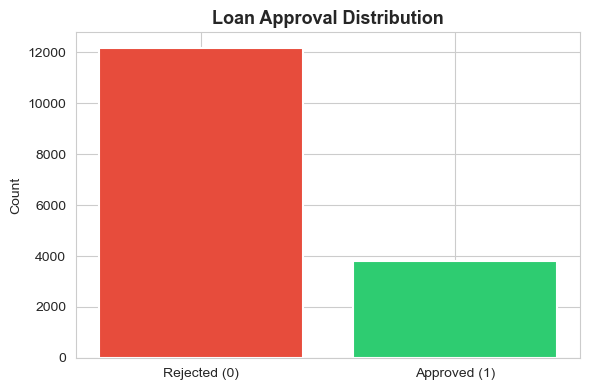

In [7]:
train_eda = X_train.copy()
train_eda['LoanApproved'] = y_train.values
counts = y_train.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Rejected (0)', 'Approved (1)'], counts,
       color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=1.5)
ax.set_title('Loan Approval Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

> **Insight:** The dataset is slightly imbalanced, with approximately 25% approved and 75% rejected loans.

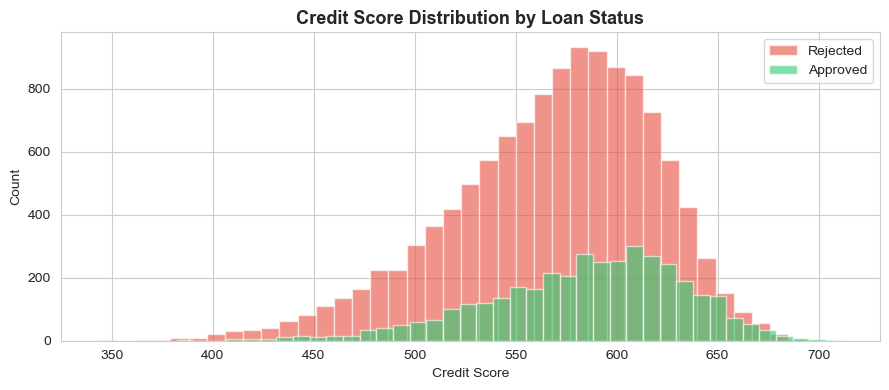

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, color, name in [(0, '#e74c3c', 'Rejected'), (1, '#2ecc71', 'Approved')]:
    subset = train_eda[train_eda['LoanApproved'] == label]['CreditScore']
    ax.hist(subset, bins=40, alpha=0.6, color=color, label=name, edgecolor='white')
ax.set_title('Credit Score Distribution by Loan Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Credit Score')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

>**Insight:** Approved applicants tend to have noticeably higher credit scores than rejected ones. This suggests that credit score is a strong predictor of loan approval.

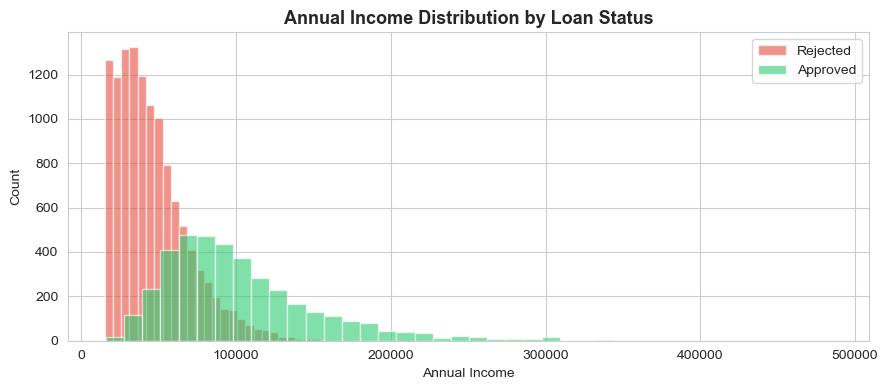

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, color, name in [(0, '#e74c3c', 'Rejected'), (1, '#2ecc71', 'Approved')]:
    subset = train_eda[train_eda['LoanApproved'] == label]['AnnualIncome']
    ax.hist(subset, bins=40, alpha=0.6, color=color, label=name, edgecolor='white')
ax.set_title('Annual Income Distribution by Loan Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Annual Income')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

>**Insight:**
> Higher annual income is associated with loan approval. Rejected applicants are more concentrated in lower income ranges, indicating that income level plays a significant role in the approval decision.

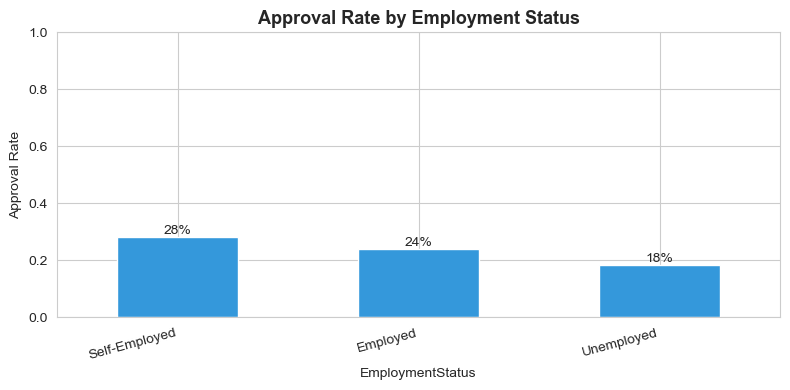

In [10]:
emp_accept = train_eda.groupby('EmploymentStatus')['LoanApproved'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
emp_accept.plot(kind='bar', color='#3498db', ax=ax, edgecolor='white')
ax.set_title('Approval Rate by Employment Status', fontsize=13, fontweight='bold')
ax.set_ylabel('Approval Rate')
ax.set_ylim(0, 1)
for i, v in enumerate(emp_accept):
    ax.text(i, v + 0.01, f'{v:.0%}', ha='center', fontsize=10)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

>**Insight:** Employed and self-employed applicants have the highest approval rates, while unemployed applicants are least likely to be approved. This reflects the lender's preference for stable income sources.

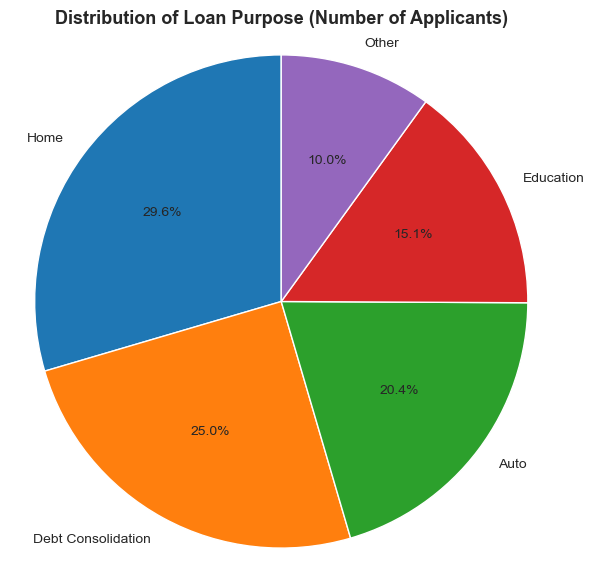

In [11]:
purpose_counts = train_eda['LoanPurpose'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(
    purpose_counts,
    labels=purpose_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Loan Purpose (Number of Applicants)', fontsize=13, fontweight='bold')
plt.axis('equal') 
plt.show()

>**Insight**: Home loans represent the largest share of applications, suggesting that real estate financing is the most common reason applicants seek loans in this dataset.

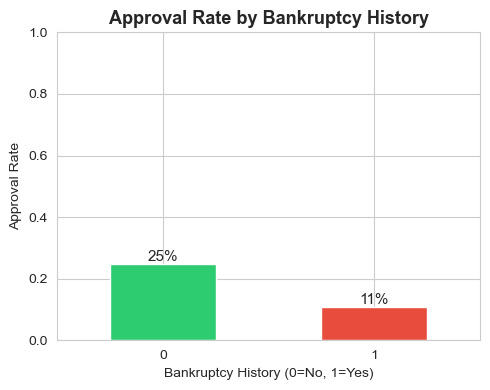

In [12]:
bk_accept = train_eda.groupby('BankruptcyHistory')['LoanApproved'].mean()
fig, ax = plt.subplots(figsize=(5, 4))
bk_accept.plot(kind='bar', color=['#2ecc71', '#e74c3c'], ax=ax, edgecolor='white')
ax.set_title('Approval Rate by Bankruptcy History', fontsize=13, fontweight='bold')
ax.set_ylabel('Approval Rate')
ax.set_xlabel('Bankruptcy History (0=No, 1=Yes)')
ax.set_ylim(0, 1)
for i, v in enumerate(bk_accept):
    ax.text(i, v + 0.01, f'{v:.0%}', ha='center', fontsize=11)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

>**Insight:** Applicants with no bankruptcy history have a significantly higher approval rate compared to those with a history of bankruptcy. This confirms that bankruptcy history is a strong negative indicator for loan approval.

---
## Step 4: Data Cleaning

In [13]:
# 4.1 Check missing values
missing = X_train.isnull().sum()
print('Missing in train:', missing[missing > 0].to_dict() if missing.sum() > 0 else 'No missing')
missing_t = X_test.isnull().sum()
print('Missing in test :', missing_t[missing_t > 0].to_dict() if missing_t.sum() > 0 else 'No missing')

Missing in train: No missing
Missing in test : No missing


In [14]:
# 4.2 Outlier Detection using IQR

all_num_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

binary_cols = [col for col in all_num_features 
               if X_train[col].dropna().isin([0, 1]).all()]
num_features = [col for col in all_num_features 
                if col not in binary_cols]


outlier_report = {}
for col in num_features:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((X_train[col] < Q1 - 1.5*IQR) | (X_train[col] > Q3 + 1.5*IQR)).sum()
    if n_out > 0:
        outlier_report[col] = n_out

print('Columns with outliers:')
for col, count in sorted(outlier_report.items(), key=lambda x: -x[1]):
    print(f'  {col}: {count} ({count/len(X_train)*100:.2f}%)')

Columns with outliers:
  SavingsAccountBalance: 1280 (8.00%)
  NetWorth: 1246 (7.79%)
  CheckingAccountBalance: 1213 (7.58%)
  TotalLiabilities: 1204 (7.52%)
  TotalAssets: 1163 (7.27%)
  TotalDebtToIncomeRatio: 922 (5.76%)
  AnnualIncome: 768 (4.80%)
  MonthlyIncome: 750 (4.69%)
  MonthlyDebtPayments: 601 (3.76%)
  LoanAmount: 591 (3.69%)
  UtilityBillsPaymentHistory: 223 (1.39%)
  JobTenure: 211 (1.32%)
  NumberOfOpenCreditLines: 205 (1.28%)
  CreditScore: 191 (1.19%)
  PaymentHistory: 182 (1.14%)
  DebtToIncomeRatio: 119 (0.74%)
  CreditCardUtilizationRate: 99 (0.62%)
  Experience: 56 (0.35%)
  Age: 41 (0.26%)
  NumberOfCreditInquiries: 12 (0.07%)


In [15]:
# 4.3 Cap outliers 
# Justification: Capping preserves all records while reducing extreme values.
# Binary columns (0/1) are excluded — no outliers possible.

X_train_cleaned = X_train.copy()
X_test_cleaned  = X_test.copy()

for col in num_features:  # num_features already excludes binary cols from step 4.2
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    X_train_cleaned[col] = X_train[col].clip(lower, upper)
    X_test_cleaned[col]  = X_test[col].clip(lower, upper)


---
## Step 5: Preprocessing (Encoding + Scaling)

In [16]:
# Define column types for ColumnTransformer
cat_cols = X_train_cleaned.select_dtypes(include='object').columns.tolist()
num_cols = num_features          # numerical only (no binary)
pass_cols = binary_cols          # binary cols pass through as-is



In [17]:
# Shared preprocessor used in all 3 pipelines
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value',
                           unknown_value=-1), cat_cols)
], remainder='passthrough')   # binary cols pass through unchanged

cv5      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svm_base = SVC(kernel='rbf', random_state=42)
results  = {}

---
## Step 6: Dimensionality Reduction 
### We compare 2 techniques: PCA vs SelectKBest


In [18]:
# ── PCA ──────────────────────────────────────
X_train_preprocessed = preprocessor.fit_transform(X_train_cleaned)
X_test_preprocessed  = preprocessor.transform(X_test_cleaned)
pca_temp = PCA(n_components=0.95, random_state=42)
X_pca= pca_temp.fit_transform(X_train_preprocessed)

scores_pca = cross_val_score(svm_base, X_pca, y_train,
                                  cv=cv5, scoring='accuracy')
results['PCA'] = scores_pca
print(f'PCA :{pca_temp.n_components_} components | '
      f'Accuracy: {scores_pca.mean()*100:.2f}% ± {scores_pca.std()*100:.2f}%')

PCA :22 components | Accuracy: 90.45% ± 0.70%


In [19]:
# ── SelectKBest ───────────────────────────────
k_values = [5, 8, 10, 12, 15]
k_scores = []

for k in k_values:
    skb   = SelectKBest(f_classif, k=k)
    X_k   = skb.fit_transform(X_train_preprocessed, y_train)
    score = cross_val_score(svm_base, X_k, y_train,
                            cv=3, scoring='accuracy').mean()
    k_scores.append(score)
    print(f'  K={k:2d} > CV Accuracy: {score*100:.2f}%')

best_k = k_values[np.argmax(k_scores)]
print(f'\nBest K = {best_k}')

skb_best = SelectKBest(f_classif, k=best_k)
X_skb= skb_best.fit_transform(X_train_preprocessed, y_train)

scores_skb= cross_val_score(svm_base, X_skb, y_train,
                                        cv=cv5, scoring='accuracy')
results['SelectKBest'] = scores_skb
print(f'SelectKBest → {best_k} features | '
      f'Accuracy: {scores_skb.mean()*100:.2f}% ± {scores_skb.std()*100:.2f}%')

  K= 5 > CV Accuracy: 88.46%
  K= 8 > CV Accuracy: 88.71%
  K=10 > CV Accuracy: 89.31%
  K=12 > CV Accuracy: 91.04%
  K=15 > CV Accuracy: 91.49%

Best K = 15
SelectKBest → 15 features | Accuracy: 91.39% ± 0.79%


In [21]:
feature_names = preprocessor.get_feature_names_out()
selected_features = feature_names[skb_best.get_support()]

print(selected_features)

['num__Age' 'num__AnnualIncome' 'num__CreditScore' 'num__Experience'
 'num__LoanAmount' 'num__LoanDuration' 'num__MonthlyDebtPayments'
 'num__LengthOfCreditHistory' 'num__TotalAssets' 'num__TotalLiabilities'
 'num__MonthlyIncome' 'num__NetWorth' 'num__TotalDebtToIncomeRatio'
 'remainder__BankruptcyHistory' 'remainder__PreviousLoanDefaults']


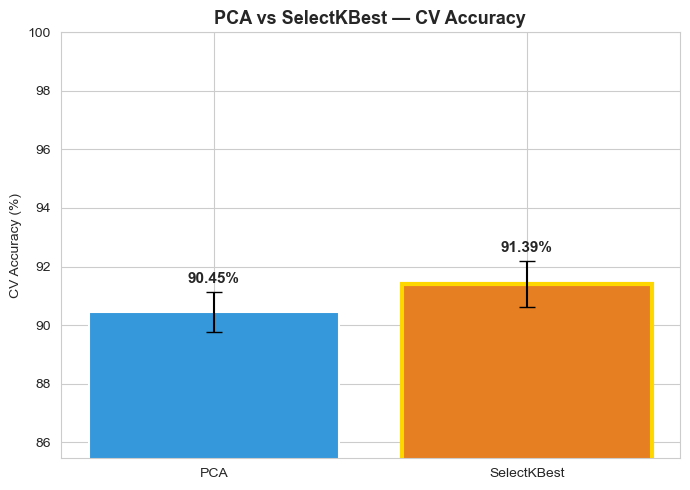


 Best Technique: SelectKBest (91.39%)


In [22]:
# ── Comparison Plot ───────────────────────────
names  = list(results.keys())
means  = [results[n].mean()*100 for n in names]
stds   = [results[n].std()*100  for n in names]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(names, means, yerr=stds, capsize=6,
              color=['#3498db', '#e67e22'],
              edgecolor='white', linewidth=1.5)
ax.set_title('PCA vs SelectKBest — CV Accuracy',
             fontsize=13, fontweight='bold')
ax.set_ylabel('CV Accuracy (%)')
ax.set_ylim(min(means)-5, 100)
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+std+0.3,
            f'{mean:.2f}%', ha='center',
            fontsize=11, fontweight='bold')
best_idx = means.index(max(means))
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(3)
plt.tight_layout()
plt.show()

best_technique = names[best_idx]
print(f'\n Best Technique: {best_technique} ({max(means):.2f}%)')

In [26]:
final_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('dr', SelectKBest(f_classif, k=best_k)),
    ('svm',SVC(random_state=42, probability=True))
])

# Param grid
param_grid = {
    'dr__k'      : [best_k],
    'svm__C'     : [0.1, 1, 10],
    'svm__kernel': ['rbf', 'linear'],
    'svm__gamma' : ['scale', 'auto']
}

grid_search = GridSearchCV(
    final_pipeline,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_cleaned, y_train)
print('\nBest Parameters:', grid_search.best_params_)
print('Best accuracy:', round(grid_search.best_score_, 4))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters: {'dr__k': 15, 'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Best accuracy: 0.9168


In [27]:
best_pipeline = grid_search.best_estimator_
y_pred        = best_pipeline.predict(X_test_cleaned)
y_proba       = best_pipeline.predict_proba(X_test_cleaned)[:, 1]

In [28]:
# 8.1 Classification Report
print('='*55)
print('FINAL MODEL EVALUATION')
print('='*55)
print(f'Dimensionality Reduction : SelectKBest (k={grid_search.best_params_["dr__k"]})')
print(f'Accuracy : {accuracy_score(y_test, y_pred)*100:.2f}%')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Approved']))

FINAL MODEL EVALUATION
Dimensionality Reduction : SelectKBest (k=15)
Accuracy : 91.67%
ROC-AUC  : 0.9679

              precision    recall  f1-score   support

    Rejected       0.94      0.95      0.95      3044
    Approved       0.84      0.80      0.82       956

    accuracy                           0.92      4000
   macro avg       0.89      0.88      0.88      4000
weighted avg       0.92      0.92      0.92      4000



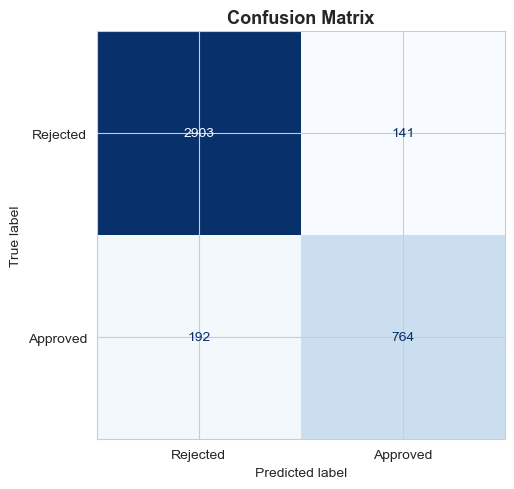

In [29]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['Rejected','Approved']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
import joblib
joblib.dump(grid_search.best_estimator_, 'loan_model.pkl')
print('Model saved!')

Model saved!
